# 01 — Dataset Exploration

IEEE-CIS Fraud Detection: shape, dtypes, class distribution, missing values, and top correlations with `isFraud`.

In [1]:
import os
import sys
from pathlib import Path

# Pin CWD to project root regardless of where the kernel launches
_here = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / 'x')).resolve()
_root = _here.parent if _here.name == '01_exploration.ipynb' else Path.cwd()
if _root.name == 'notebooks':
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root / 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from fraud_detection.data.load import load_dataset

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print(f'Working directory: {Path.cwd()}')

Working directory: C:\Users\visha\Projects\fraud-detection


## 1. Load data

In [2]:
df = load_dataset('config/config.yaml')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Shape: 590,540 rows × 434 columns


## 2. Shape & dtypes

In [3]:
dtype_counts = df.dtypes.value_counts().rename_axis('dtype').reset_index(name='count')
print('Column dtype breakdown:')
print(dtype_counts.to_string(index=False))

Column dtype breakdown:


  dtype  count
float64    399
    str     31
  int64      4


In [4]:
groups = {
    'V features (anon)':      [c for c in df.columns if c.startswith('V')],
    'C features (count)':     [c for c in df.columns if c.startswith('C') and c[1:].isdigit()],
    'D features (timedelta)': [c for c in df.columns if c.startswith('D') and c[1:].isdigit()],
    'M features (match)':     [c for c in df.columns if c.startswith('M') and c[1:].isdigit()],
    'id features':            [c for c in df.columns if c.startswith('id_')],
    'card features':          [c for c in df.columns if c.startswith('card')],
    'addr features':          [c for c in df.columns if c.startswith('addr')],
    'Other':                  ['TransactionID','TransactionDT','TransactionAmt','ProductCD',
                                'dist1','dist2','P_emaildomain','R_emaildomain',
                                'DeviceType','DeviceInfo','isFraud'],
}

for name, cols in groups.items():
    actual = [c for c in cols if c in df.columns]
    print(f'{name:30s}: {len(actual):4d} columns')

V features (anon)             :  339 columns
C features (count)            :   14 columns
D features (timedelta)        :   15 columns
M features (match)            :    9 columns
id features                   :   38 columns
card features                 :    6 columns
addr features                 :    2 columns
Other                         :   11 columns


## 3. Class distribution

In [5]:
fraud_counts = df['isFraud'].value_counts().sort_index()
fraud_rate   = df['isFraud'].mean()

print(f'Legitimate transactions : {fraud_counts[0]:>8,}  ({1-fraud_rate:.3%})')
print(f'Fraudulent transactions : {fraud_counts[1]:>8,}  ({fraud_rate:.3%})')
print(f'Imbalance ratio         : {fraud_counts[0]/fraud_counts[1]:.1f}:1')

Legitimate transactions :  569,877  (96.501%)
Fraudulent transactions :   20,663  (3.499%)
Imbalance ratio         : 27.6:1


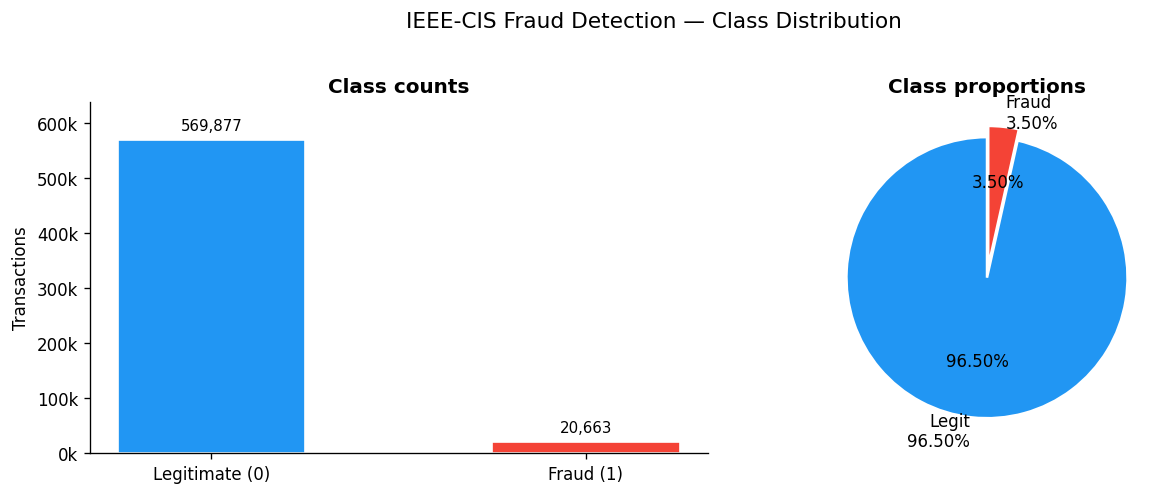

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
bars = ax.bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values,
              color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
ax.bar_label(bars, labels=[f'{v:,}' for v in fraud_counts.values], padding=4, fontsize=9)
ax.set_title('Class counts', fontweight='bold')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_ylim(0, fraud_counts[0] * 1.12)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.pie(fraud_counts.values,
       labels=[f'Legit\n{1-fraud_rate:.2%}', f'Fraud\n{fraud_rate:.2%}'],
       colors=['#2196F3', '#F44336'],
       explode=[0, 0.08],
       autopct='%1.2f%%',
       startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Class proportions', fontweight='bold')

plt.suptitle('IEEE-CIS Fraud Detection — Class Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Missing values

In [7]:
missing = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      .rename('missing_rate')
      .to_frame()
)
missing['missing_count'] = (missing['missing_rate'] * len(df)).astype(int)

thresholds = [0.0, 0.2, 0.5, 0.7, 1.0]
labels      = ['0%', '0–20%', '20–50%', '50–70%', '70–100%']

print('Missing-value summary by threshold:')
for lo, hi, label in zip(thresholds, thresholds[1:], labels[1:]):
    n = ((missing['missing_rate'] > lo) & (missing['missing_rate'] <= hi)).sum()
    print(f'  {label:>10s}: {n:4d} features')

print(f'\nFeatures with 0% missing  : {(missing["missing_rate"] == 0).sum()}')
print(f'Features with any missing : {(missing["missing_rate"] > 0).sum()}')
print(f'\nTop-20 highest-missing features:')
print(missing.head(20).to_string())

Missing-value summary by threshold:
       0–20%:  162 features
      20–50%:   38 features
      50–70%:    6 features
     70–100%:  208 features

Features with 0% missing  : 20
Features with any missing : 414

Top-20 highest-missing features:
       missing_rate  missing_count
id_24        0.9920         585793
id_25        0.9913         585408
id_07        0.9913         585385
id_08        0.9913         585385
id_21        0.9913         585381
id_26        0.9913         585377
id_27        0.9912         585371
id_23        0.9912         585371
id_22        0.9912         585371
dist2        0.9363         552913
D7           0.9341         551623
id_18        0.9236         545427
D13          0.8951         528588
D14          0.8947         528353
D12          0.8904         525823
id_04        0.8877         524216
id_03        0.8877         524216
D6           0.8761         517353
id_33        0.8759         517251
id_09        0.8731         515614


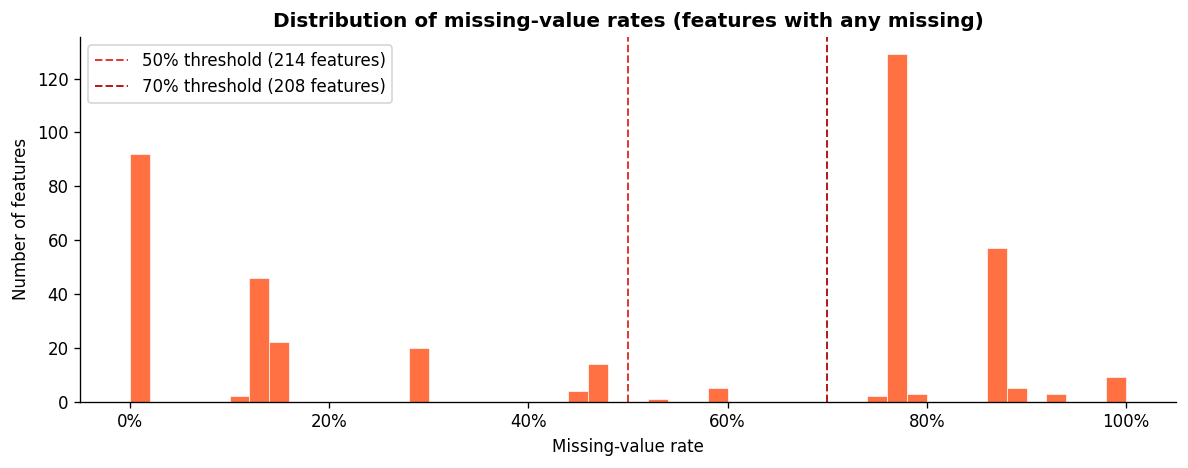

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

rates = missing['missing_rate'].values
bins  = np.linspace(0, 1, 51)
ax.hist(rates[rates > 0], bins=bins, color='#FF7043', edgecolor='white', linewidth=0.4)

for thresh, label, color in [(0.5, '50%', '#E53935'), (0.7, '70%', '#B71C1C')]:
    ax.axvline(thresh, color=color, linestyle='--', linewidth=1.2,
               label=f'{label} threshold ({(rates > thresh).sum()} features)')

ax.set_xlabel('Missing-value rate')
ax.set_ylabel('Number of features')
ax.set_title('Distribution of missing-value rates (features with any missing)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/missing_values.png', bbox_inches='tight')
plt.show()

## 5. Top feature correlations with isFraud

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ('TransactionID', 'TransactionDT', 'isFraud')]

corr = (
    df[numeric_cols + ['isFraud']]
    .corr()['isFraud']
    .drop('isFraud')
    .sort_values(key=abs, ascending=False)
)

top_n = 30
top_corr = corr.head(top_n)

print(f'Top {top_n} numeric features by |correlation| with isFraud:')
print(top_corr.to_string())

Top 30 numeric features by |correlation| with isFraud:
V257   0.3831
V246   0.3669
V244   0.3641
V242   0.3606
V201   0.3280
V200   0.3188
V189   0.3082
V188   0.3036
V258   0.2972
V45    0.2818
V158   0.2781
V156   0.2760
V149   0.2733
V228   0.2689
V44    0.2604
V86    0.2518
V87    0.2517
V170   0.2498
V147   0.2429
V52    0.2395
V157   0.2349
V155   0.2342
V230   0.2317
V199   0.2310
V148   0.2289
V51    0.2232
V171   0.2165
V40    0.2124
V243   0.2102
V154   0.2070


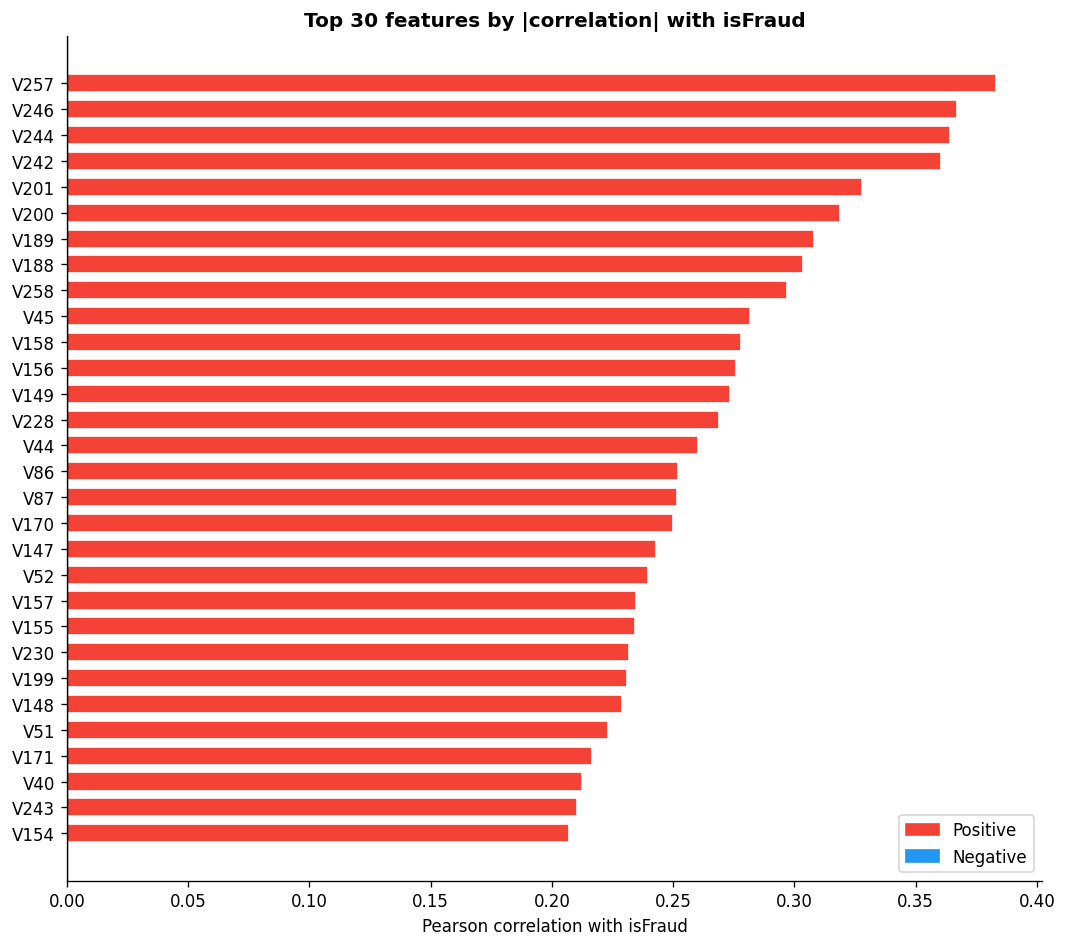

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))

colors = ['#F44336' if v > 0 else '#2196F3' for v in top_corr.values]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1],
        edgecolor='white', height=0.7)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with isFraud')
ax.set_title(f'Top {top_n} features by |correlation| with isFraud', fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#F44336', label='Positive'), Patch(color='#2196F3', label='Negative')],
          loc='lower right')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/top_correlations.png', bbox_inches='tight')
plt.show()

## 6. Transaction amount by class

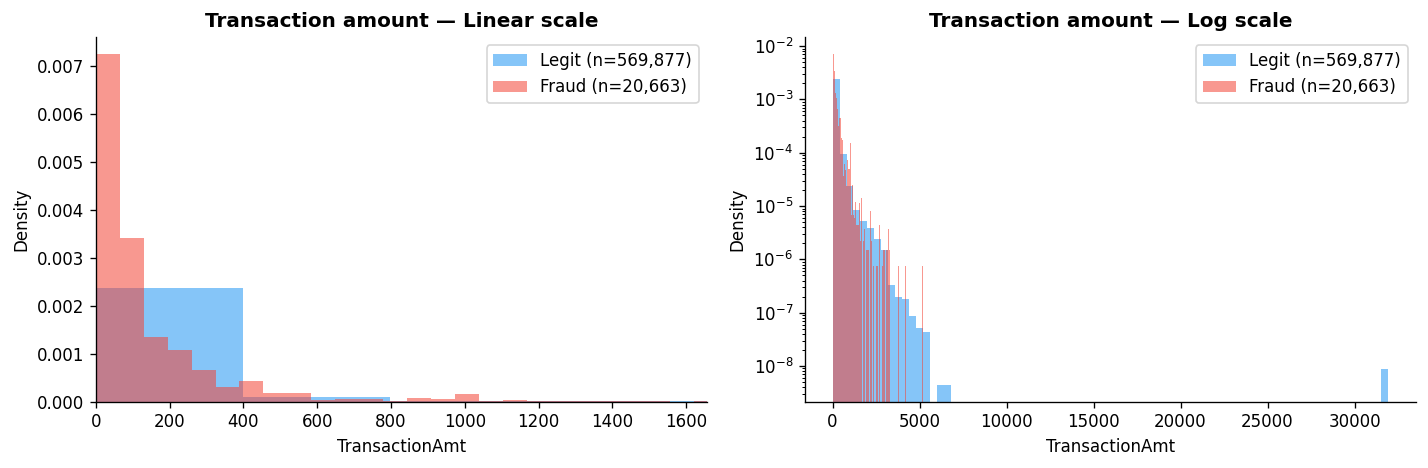

              count     mean      std    min     25%     50%      75%  \
isFraud                                                                 
0       569877.0000 134.5117 239.3951 0.2510 43.9700 68.5000 120.0000   
1        20663.0000 149.2448 232.2122 0.2920 35.0440 75.0000 161.0000   

               max  
isFraud             
0       31937.3910  
1        5191.0000  


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, log_scale, title in zip(axes, [False, True], ['Linear scale', 'Log scale']):
    for label, color in [(0, '#2196F3'), (1, '#F44336')]:
        vals = df.loc[df['isFraud'] == label, 'TransactionAmt']
        ax.hist(vals, bins=80, alpha=0.55, color=color,
                label=f'{"Legit" if label==0 else "Fraud"} (n={len(vals):,})',
                density=True, log=log_scale)
    ax.set_xlabel('TransactionAmt')
    ax.set_ylabel('Density')
    ax.set_title(f'Transaction amount — {title}', fontweight='bold')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    if not log_scale:
        ax.set_xlim(0, df['TransactionAmt'].quantile(0.995))

plt.tight_layout()
plt.savefig('reports/figures/transaction_amount.png', bbox_inches='tight')
plt.show()

print(df.groupby('isFraud')['TransactionAmt'].describe())

## 7. Time-series fraud rate

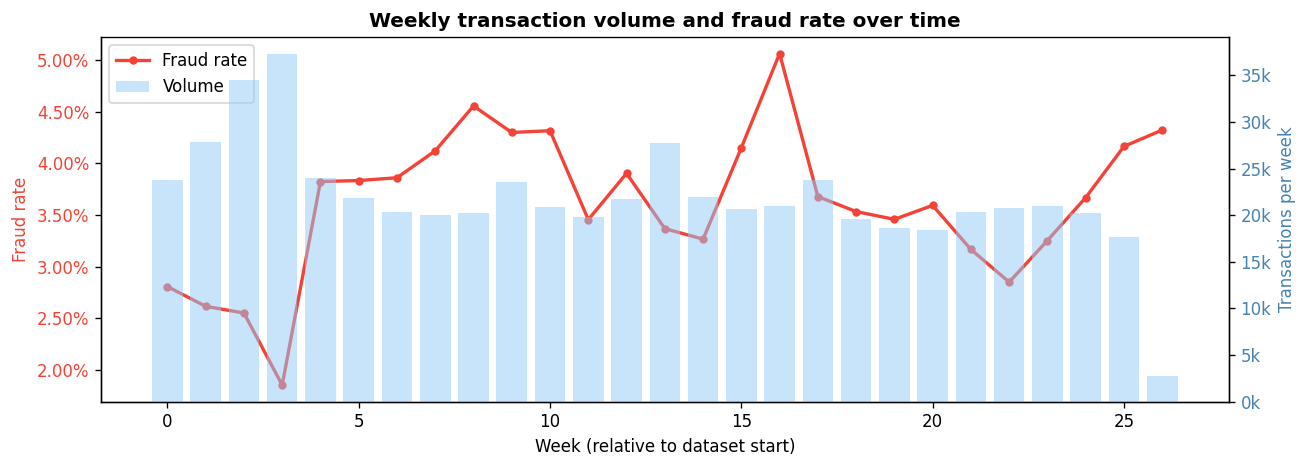

In [12]:
seconds_per_week = 7 * 24 * 3600
df['week'] = (df['TransactionDT'] // seconds_per_week).astype(int)

weekly = df.groupby('week')['isFraud'].agg(['mean', 'count']).reset_index()
weekly.columns = ['week', 'fraud_rate', 'n_transactions']

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax2.bar(weekly['week'], weekly['n_transactions'], color='#90CAF9', alpha=0.5, label='Volume')
ax1.plot(weekly['week'], weekly['fraud_rate'], color='#F44336', linewidth=2,
         marker='o', markersize=4, label='Fraud rate')

ax1.set_xlabel('Week (relative to dataset start)')
ax1.set_ylabel('Fraud rate', color='#F44336')
ax1.tick_params(axis='y', labelcolor='#F44336')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax2.set_ylabel('Transactions per week', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

ax1.set_title('Weekly transaction volume and fraud rate over time', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.spines[['top']].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/weekly_fraud_rate.png', bbox_inches='tight')
plt.show()

df.drop(columns=['week'], inplace=True)

## Summary

| Metric | Value |
|--------|-------|
| Rows | 590,540 |
| Columns (merged) | 434 |
| Fraud rate | ~3.5% |
| Identity coverage | ~24.4% of transactions |
| Features with >50% missing | ~214 |

**Key observations:**
- Severe class imbalance (~28:1). Stratified sampling and class-weight handling required.
- ~75% of transactions have no identity record — identity features will be sparse.
- Many V-features have very high missing rates; the 70% threshold in config will prune a large portion.
- `TransactionAmt`, several V-features, and C-features show the highest correlations with fraud.
- Fraud rate is relatively stable over time with slight weekly variation — walk-forward split is appropriate.